### 1.解析HEST项目结构，提取要预测的基因子集

In [ ]:
import os.path as osp
import os
import anndata # type: ignore
import numpy as np
import pandas as pd
from scipy.sparse import issparse

In [ ]:

def get_genes(hest_dir, wsi_dir, st_dir, gene_file_path):
    """
    从指定的数据集中筛选出在所有样本中共同存在且总表达量最高的250个基因。

    Args:
        hest_dir (str): HEST 数据集子集的根目录。
        wsi_dir (str): 包含 .tif 文件的 WSI 目录。
        st_dir (str): 包含 .h5ad 文件的 ST 目录。
        gene_file_path (str): 筛选出的基因列表的保存路径 (.npy)。
    """
    files = os.listdir(wsi_dir)
    names = []
    for i in files:
        if i.endswith('.tif'):
            names.append(i.split('.')[0])
    
    # 用于存储所有样本中每个基因的总表达量
    all_gene_expression_sum = {}
    # 用于存储每个样本的基因集合，以计算交集
    gene_sets_per_sample = []
    
    for i in names:
        st_file = osp.join(st_dir, i + '.h5ad')
        
        if not osp.exists(st_file):
            print(f"跳过文件: {st_file} (文件不存在)")
            continue
            
        print(f"处理文件: {st_file}")
        
        try:
            adata = anndata.read_h5ad(st_file)
        except Exception as e:
            print(f"读取 {st_file} 失败: {e}")
            continue

        X = adata.X
        gene_names = adata.var_names
        
        # --- 新增步骤 1: 记录当前样本的基因集合 ---
        gene_sets_per_sample.append(set(gene_names))
        
        # 计算每个基因的总表达量
        if issparse(X):
            gene_sum = np.array(X.sum(axis=0)).flatten()
        else:
            gene_sum = np.sum(X, axis=0)
        
        gene_expression_series = pd.Series(gene_sum, index=gene_names)
        
        # 累加每个样本的基因表达量总和
        for gene, total_exp in gene_expression_series.items():
            all_gene_expression_sum[gene] = all_gene_expression_sum.get(gene, 0) + total_exp

        print(f"样本 {i} 已处理。")

    # --- 筛选基因的核心逻辑 ---
    
    if not all_gene_expression_sum or not gene_sets_per_sample:
        print("警告: 未检测到有效的基因表达数据，无法进行筛选。")
        return None
        
    # --- 新增步骤 2: 计算所有样本共有的基因交集 ---
    # 使用 set.intersection() 计算多个集合的交集
    common_genes = set.intersection(*gene_sets_per_sample)
    print(f"\n在所有 {len(names)} 个样本中，共找到 {len(common_genes)} 个共同存在的基因。")
    
    if not common_genes:
        print("警告: 所有样本之间没有共同的基因，无法进行筛选。")
        return None

    # 将累加的总表达量转换为 Series
    all_gene_expression_sum_series = pd.Series(all_gene_expression_sum)
    
    # --- 新增步骤 3: 只在共同基因的范围内进行筛选 ---
    # 从总表达量 Series 中，只选取那些存在于 common_genes 集合中的基因
    common_gene_expression = all_gene_expression_sum_series[all_gene_expression_sum_series.index.isin(common_genes)]
    
    # 按照表达量降序排列
    sorted_common_genes = common_gene_expression.sort_values(ascending=False)
    
    # 检查共同基因的数量是否足够250个
    num_to_select = min(250, len(sorted_common_genes))
    if len(sorted_common_genes) < 250:
        print(f"警告: 共同基因数量 ({len(sorted_common_genes)}) 少于250个，将只选取这 {num_to_select} 个基因。")
        
    # 选取表达量最高的 num_to_select 个基因的名称
    top_gene_names = sorted_common_genes.head(num_to_select).index.to_numpy()
    
    print("\n" + "="*20 + " 筛选结果 " + "="*20)
    print(f"已筛选出在所有样本中共同存在且总表达量最高的 {num_to_select} 个基因。")
    
    # --- 新增步骤 4: 打印筛选出的基因列表 ---
    print("\n筛选出的基因列表:")
    # 为了方便查看，每行打印10个基因
    for j in range(0, len(top_gene_names), 10):
        print(" ".join(top_gene_names[j:j+10]))
    print("="*52)
    
    # 将结果保存到 .npy 文件
    try:
        # 确保保存路径的目录存在
        save_dir = osp.dirname(gene_file_path)
        if not osp.exists(save_dir):
            os.makedirs(save_dir)
            
        np.save(gene_file_path, top_gene_names)
        print(f"\n✅ 已将筛选出的 {num_to_select} 个基因名称保存到: {gene_file_path}")
        
    except Exception as e:
        print(f"\n❌ 保存 .npy 文件失败: {e}")


In [ ]:
# HEST-LUAD
hest_dir = './data/hest_data_LUAD'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_LUAD_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-PAAD
hest_dir = './data/hest_data_PAAD'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_PAAD_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-IDC
hest_dir = './data/hest_data_IDC'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_IDC_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-SKCM
hest_dir = './data/hest_data_SKCM'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_SKCM_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-SKCM
hest_dir = './data/hest_data_SKCM'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_SKCM_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-KIDNEY
hest_dir = './data/hest1k_datasets/kidney'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_KIDNEY_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-MOUBRAIN
hest_dir = './data/hest1k_datasets/mouse_brain'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_MOUSE_BRAIN_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
# HEST-PRAD
hest_dir = './data/hest1k_datasets/PRAD'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_PRAD_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

In [ ]:
import os
import os.path as osp
import anndata

def find_optimal_subset_branch_and_bound(st_dir, min_common_genes=250):
    """
    使用分支定界法 (Branch and Bound) 找到满足条件的绝对最大的样本子集。

    此方法保证找到全局最优解，同时通过“剪枝”策略避免了完全的暴力搜索，
    在速度上远胜于暴力搜索，尤其在样本数量较多时。

    Args:
        st_dir (str): 包含 .h5ad 文件的 ST 目录。
        min_common_genes (int): 要求的最小共同基因数量阈值。默认为 250。

    Returns:
        list or None: 如果找到，返回最大的样本子集列表；否则返回 None。
    """
    # --- 步骤 1: 预加载所有样本的基因集合 ---
    print("--- 步骤 1: 正在预加载所有样本的基因数据 ---")
    sample_gene_sets = {}
    all_files = os.listdir(st_dir)
    
    for filename in all_files:
        if not filename.endswith('.h5ad'):
            continue
        sample_name = filename.split('.')[0]
        st_file = osp.join(st_dir, filename)
        try:
            adata = anndata.read_h5ad(st_file)
            sample_gene_sets[sample_name] = set(adata.var_names)
            print(f"  - 已加载样本 '{sample_name}'")
        except Exception as e:
            print(f"  - 警告: 读取 {st_file} 失败，已跳过。错误: {e}")

    # 为了算法的确定性，对样本名进行排序
    all_sample_names = sorted(list(sample_gene_sets.keys()))
    num_samples = len(all_sample_names)
    
    if num_samples < 1:
        print("\n错误: 未加载到任何有效样本。")
        return None

    print(f"\n--- 步骤 2: 开始执行分支定界算法 (共 {num_samples} 个样本) ---")
    
    # 全局变量，用于在递归中跟踪找到的最佳子集
    best_subset = []

    def backtrack(start_index, current_subset, current_intersection):
        nonlocal best_subset

        # --- 定界 (Bounding) / 剪枝 ---
        # 潜力评估：如果当前子集的大小 + 剩余未检查的样本数 <= 已找到的最佳子集大小，
        # 那么这条路不可能产生更好的结果了，直接剪掉。
        # 这是整个算法加速的核心！
        potential_max_size = len(current_subset) + (num_samples - start_index)
        if potential_max_size <= len(best_subset):
            return

        # --- 分支 (Branching) ---
        # 遍历剩余的样本，尝试将它们加入 current_subset
        for i in range(start_index, num_samples):
            sample_name = all_sample_names[i]
            
            # 再次进行剪枝，这是一个更紧的界
            if len(current_subset) + (num_samples - i) <= len(best_subset):
                return

            # 尝试将新样本加入子集，并计算新的交集
            new_intersection = current_intersection.intersection(sample_gene_sets[sample_name])

            # 检查新交集是否仍然满足条件
            if len(new_intersection) >= min_common_genes:
                new_subset = current_subset + [sample_name]
                
                # 如果当前找到的这个子集比之前最好的还要大，就更新最佳答案
                if len(new_subset) > len(best_subset):
                    best_subset = new_subset
                    print(f"  -> 发现一个更大的有效子集，大小为: {len(best_subset)}, 样本: {best_subset}")

                # 继续向下递归，寻找更大的可能性
                backtrack(i + 1, new_subset, new_intersection)

    # 算法的起点：从一个空集开始，对所有样本进行初始分支
    for i in range(num_samples):
        # 剪枝：如果从当前点开始，所有剩余样本加起来都不如已找到的 best_subset 大，就提前结束
        if num_samples - i <= len(best_subset):
            break
            
        initial_sample = all_sample_names[i]
        initial_set = sample_gene_sets[initial_sample]
        
        # 检查单个样本的基因数是否达标（虽然不太可能不达标，但逻辑上是需要的）
        if len(initial_set) >= min_common_genes:
            # 如果当前还没有找到任何解，那么单个样本本身就是一个解
            if len(best_subset) == 0:
                best_subset = [initial_sample]
                print(f"  -> 发现一个更大的有效子集，大小为: 1, 样本: {best_subset}")

            # 从这个样本开始，向后递归探索
            backtrack(i + 1, [initial_sample], initial_set)

    # --- 最终结果 ---
    if best_subset:
        print("\n" + "="*20 + " 搜索完成，找到最优解! " + "="*20)
        print(f"最大的有效子集大小为: {len(best_subset)}")
        print(f"该子集共同基因数 >= {min_common_genes}")
        print("\n子集中的样本列表:")
        for i in range(0, len(best_subset), 5):
             print("  ".join(best_subset[i:i+5]))
        print("="*62)
        return best_subset
    else:
        print("\n" + "="*20 + " 未找到解决方案 " + "="*20)
        print(f"在所有样本中，无法找到任何子集使其共同基因数量达到 {min_common_genes} 个。")
        print("="*62)
        return None

In [ ]:
BASE_DIR = './data/hest1k_datasets/Liver' 

# WSI 文件 (.tif) 所在的目录
WSI_DIR = osp.join(BASE_DIR, 'wsis') 

# ST 文件 (.h5ad) 所在的目录
ST_DIR = osp.join(BASE_DIR, 'st') 

# 寻找最大子集，要求共同基因至少有 250 个
largest_subset = find_optimal_subset_branch_and_bound(st_dir=ST_DIR, min_common_genes=250)

if largest_subset:
    print("\n最终得到的最大样本子集是:", largest_subset)
else:
    print("\n未能找到符合条件的样本子集。")

# # 您也可以尝试一个更宽松的条件
# print("\n--- 尝试一个更宽松的条件 (100个共同基因) ---")
# largest_subset_100 = find_largest_sample_subset(st_dir=ST_DIR, min_common_genes=100)

# if largest_subset_100:
#     print("\n最终得到的最大样本子集是:", largest_subset_100)

In [ ]:
# HEST-Liver
hest_dir = './data/hest1k_datasets/Lung'
wsi_dir  = osp.join(hest_dir , 'wsis')
st_dir   = osp.join(hest_dir , 'st')
save_dir = 'select_genes'
g_f_path = osp.join(save_dir , 'HEST_LUNG_gene.npy')
get_genes(hest_dir, wsi_dir, st_dir, g_f_path)

##### 2. Patches 位置信息

###### 2.1 Debug 一下 patch 和 st 的坐标信息，可以忽略

In [ ]:
import anndata
import os.path as osp
import pandas as pd
import numpy as np

st_dir  = './data/hest_data_LUAD/st'
st_file_name = 'TENX141.h5ad'
file_path = osp.join(st_dir, st_file_name) 

try:
    if not osp.exists(file_path):
        print(f"❌ 错误：文件路径不存在或未替换: {file_path}")
    else:
        # 1. 读取 AnnData 对象
        adata = anndata.read_h5ad(file_path)
        
        # 2. 提取 Barcode 和 WSI 像素坐标
        # AnnData 对象的 .obs 属性本质上是一个 Pandas DataFrame
        coords_df = adata.obs[['pxl_col_in_fullres', 'pxl_row_in_fullres']].copy()
        
        print(f"\n✅ 成功提取 Barcode 和对应的 WSI 像素坐标。")
        print(f"总共有 {len(coords_df)} 个 Spot/Patch 坐标。")
        print("-" * 50)
        
        # 3. 打印前 100 个 Barcode 及其对应的坐标
        num_to_print = min(100, len(coords_df))
        print(f"--- 前 {num_to_print} 个 Barcode 及其 WSI 像素坐标 ---")
        
        # 使用 Pandas 打印前 N 行，更清晰地展示 Barcode (索引) 和坐标 (列) 的对应关系
        print(coords_df.head(num_to_print).to_string())
        
        print("-" * 50)
        print("注意：")
        print("1. 第一列（000x000 等）即为 **Barcode**。")
        print("2. 'pxl_col_in_fullres' (X) 和 'pxl_row_in_fullres' (Y) 是 **Spot/Patch 的中心 WSI 像素坐标**。")

except FileNotFoundError:
    print(f"❌ 文件未找到：请检查路径是否正确。")
except Exception as e:
    print(f"❌ 读取 AnnData 文件时发生错误: {e}")

In [ ]:
import h5py
import os.path as osp

patch_file_path = "./data/hest_data_LUAD/patches/TENX141.h5"

try:
    if not osp.exists(patch_file_path):
        print(f"❌ 错误：文件路径不存在或未替换: {patch_file_path}")
    else:
        print(f"--- 正在分析 HDF5 文件: {osp.basename(patch_file_path)} ---")
        
        # 以只读模式打开 HDF5 文件
        with h5py.File(patch_file_path, 'r') as f:
            print("\n📂 文件内部结构 (Keys/Datasets):")
            
            # 遍历文件根目录下的所有键（组或数据集）
            for key in f.keys():
                item = f[key]
                print(f"  Key: {key} (Type: {type(item).__name__})")
                
                # 如果是数据集，打印其形状和数据类型
                if isinstance(item, h5py.Dataset):
                    print(f"    - 形状 (Shape): {item.shape}")
                    print(f"    - 类型 (Dtype): {item.dtype}")

            print("\n🔍 重点关注：")
            print("1. 形状为 (N, 224, 224, 3) 的数据集 (Patch 图像数据)。")
            print("2. 形状为 (N,) 且 dtype 为字符串的数据集 (Barcode)。")

except Exception as e:
    print(f"❌ 读取 HDF5 文件时发生错误: {e}")

In [ ]:
import anndata
import h5py
import os.path as osp
import pandas as pd
import numpy as np

# --- 文件路径设置 ---
st_dir = './data/hest_data_IDC/st'
st_file_name = 'SPA0.h5ad'
ad_file_path = osp.join(st_dir, st_file_name) 

patch_file_path = "./data/hest_data_IDC/patches/SPA0.h5"
output_dir = './data/hest_data_IDC/' # 假设的输出目录
output_file_name = f'SPA0_filtered_spots_info.csv'
output_path = osp.join(output_dir, output_file_name)

# --- 1. 重新获取被过滤的 Barcode ---
try:
    # 提取保留的 Barcode (从 .h5 文件)
    with h5py.File(patch_file_path, 'r') as f:
        barcodes_retained_raw = f['barcode'][:]
        barcodes_retained = [b[0].decode('utf-8') for b in barcodes_retained_raw]
    
    # 提取所有 Barcode (从 .h5ad 文件)
    adata = anndata.read_h5ad(ad_file_path)
    barcodes_all = adata.obs_names.tolist()
    
    # 计算差集
    set_retained = set(barcodes_retained)
    set_all = set(barcodes_all)
    barcodes_filtered = sorted(list(set_all - set_retained))
    
    num_filtered = len(barcodes_filtered)
    print(f"🔬 找到 {num_filtered} 个被过滤的 Spot。")

    if num_filtered == 0:
        print("没有 Spot 被过滤，程序中止。")
    else:
        # --- 2. 提取所有被过滤 Spot 的完整 QC 信息 ---
        
        # 索引 AnnData 对象
        adata_filtered = adata[barcodes_filtered, :].copy()
        
        # 提取所有相关的 QC 和空间信息
        filtered_qc_info = adata_filtered.obs.copy()
        
        # --- 3. 打印前 20 个 Spot 的信息 ---
        print("-" * 60)
        print(f"--- 被过滤 Spot 的完整 QC 信息 (前 20 个) ---")
        # to_string() 确保所有列都能显示出来
        print(filtered_qc_info.head(20).to_string())
        print("-" * 60)
        
        # --- 4. 保存到 CSV 文件 ---
        filtered_qc_info.to_csv(output_path, index=True, index_label='Barcode')
        
        print(f"\n✅ 已将所有 {num_filtered} 个被过滤 Spot 的信息保存到：")
        print(f"   {output_path}")
        print("您现在可以在该 CSV 文件中查看全部 Spot 的数据。")

except Exception as e:
    print(f"❌ 执行过程中发生错误: {e}")

AnnData object with n_obs × n_vars = 370 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'
数据准备就绪，用于绘制 370 个 Spot 的质量指标图。


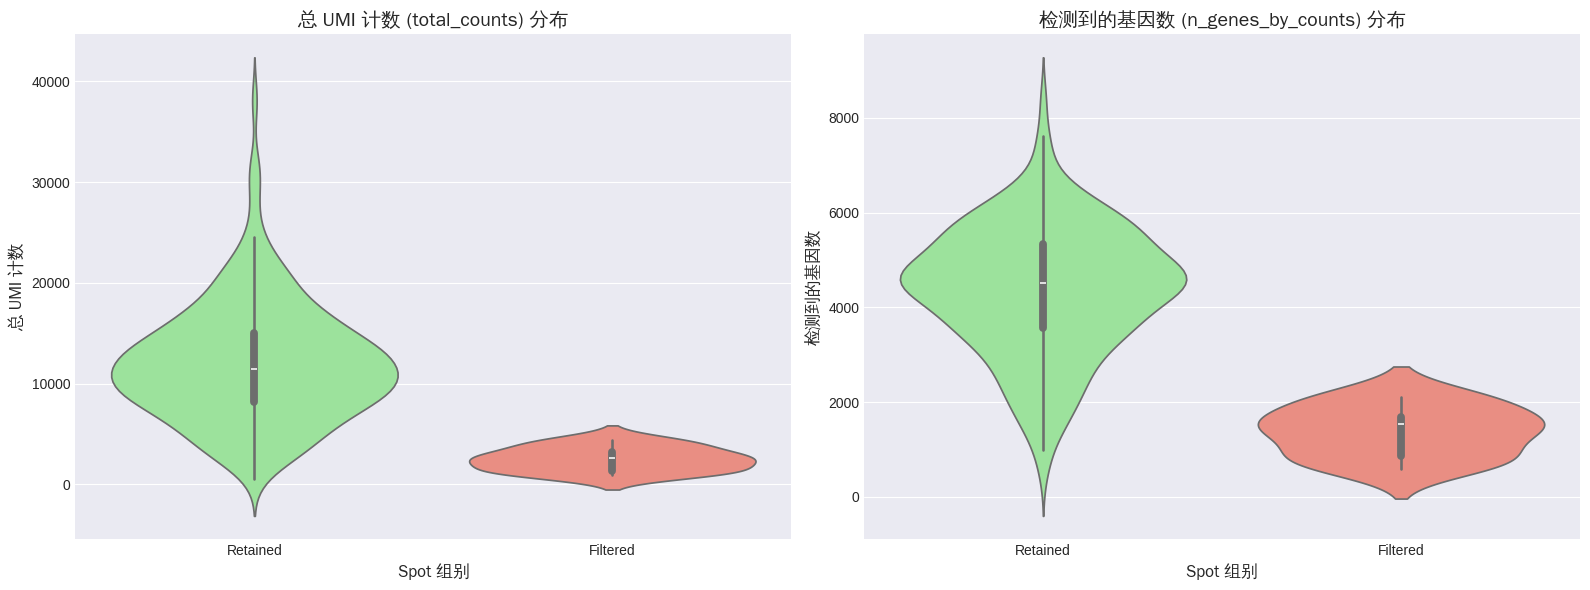


💡 图表解读：
  - 左侧是总 UMI 计数 (total_counts) 分布，右侧是检测到的基因数 (n_genes_by_counts) 分布。
  - 绿色的 'Retained' 小提琴图将明显高于红色的 'Filtered' 图，直观地证明了过滤的有效性。


In [1]:
import anndata
import h5py
import os.path as osp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
import scanpy as sc # 👈 【新增】导入 Scanpy 用于计算指标

# --- 🎯 您的字体文件路径 ---
# 请确保该路径下的字体文件存在，否则中文显示仍会失败
FONT_PATH = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc" 

# --- 文件路径设置 (与之前相同) ---
st_dir = './data/hest1k_datasets/kidney/st'
st_file_name = 'NCBI692.h5ad'
ad_file_path = osp.join(st_dir, st_file_name) 
patch_file_path = "./data/hest1k_datasets/kidney/patches/NCBI692.h5"

try:
    # 1. 字体和编码配置
    # 创建 FontProperties 对象，指向您的字体文件
    zh_font = FontProperties(fname=FONT_PATH, size=14)
    plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
    
    # 2. 获取 AnnData 对象并计算 QC 指标
    adata = anndata.read_h5ad(ad_file_path)
    print(adata)
    
    # 【关键修正】：使用 Scanpy 计算 QC 指标 (total_counts, n_genes_by_counts 等)
    sc.pp.calculate_qc_metrics(adata, inplace=True) 
    
    # 3. 读取 Patch 文件中的保留 Barcode
    with h5py.File(patch_file_path, 'r') as f:
        barcodes_retained_raw = f['barcode'][:]
        # 统一处理 bytes/numpy.bytes_ 类型，解码为字符串
        barcodes_retained = [b[0].decode('utf-8') if isinstance(b, np.ndarray) and b.dtype.type is np.bytes_ else b.item().decode('utf-8') for b in barcodes_retained_raw]
    
    # 4. 识别过滤和保留的 Spot 组，并创建绘图 DataFrame
    barcodes_all = adata.obs_names.tolist()
    set_retained = set(barcodes_retained)
    barcodes_filtered = list(set(barcodes_all) - set_retained)
    
    # 【修正点】：使用正确的列名 'total_counts'
    plot_df = adata.obs[['total_counts', 'n_genes_by_counts']].copy()
    plot_df['Group'] = 'Retained'
    plot_df.loc[barcodes_filtered, 'Group'] = 'Filtered'
    
    print(f"数据准备就绪，用于绘制 {len(plot_df)} 个 Spot 的质量指标图。")
    
    # --- 5. 绘制小提琴图 ---
    
    plt.style.use('seaborn-v0_8-darkgrid') 
    fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
    
    # 统一设置调色板
    palette_map = {'Retained': 'lightgreen', 'Filtered': 'salmon'}
    
    # 子图 1: total_counts (总 UMI 计数)
    # 【修正点】：使用正确的 y 轴变量 'total_counts'
    sns.violinplot(x='Group', y='total_counts', data=plot_df, ax=axes[0], 
                   hue='Group', palette=palette_map, legend=False)
    
    # 【修正点】：标题和标签文本修正
    axes[0].set_title('总 UMI 计数 (total_counts) 分布', fontproperties=zh_font, fontsize=14)
    axes[0].set_ylabel('总 UMI 计数', fontproperties=zh_font, fontsize=12)
    axes[0].set_xlabel('Spot 组别', fontproperties=zh_font, fontsize=12)
    axes[0].tick_params(axis='x', labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)
    
    # 子图 2: n_genes_by_counts (检测到的基因数)
    sns.violinplot(x='Group', y='n_genes_by_counts', data=plot_df, ax=axes[1], 
                   hue='Group', palette=palette_map, legend=False)
                        
    axes[1].set_title('检测到的基因数 (n_genes_by_counts) 分布', fontproperties=zh_font, fontsize=14)
    axes[1].set_ylabel('检测到的基因数', fontproperties=zh_font, fontsize=12)
    axes[1].set_xlabel('Spot 组别', fontproperties=zh_font, fontsize=12)
    axes[1].tick_params(axis='x', labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)

    plt.tight_layout() 
    plt.show()

    print("\n💡 图表解读：")
    print("  - 左侧是总 UMI 计数 (total_counts) 分布，右侧是检测到的基因数 (n_genes_by_counts) 分布。")
    print("  - 绿色的 'Retained' 小提琴图将明显高于红色的 'Filtered' 图，直观地证明了过滤的有效性。")

except Exception as e:
    print(f"❌ 执行过程中发生错误: {e}")

In [ ]:
import h5py
import os.path as osp

# 🚨 请确保这个路径是正确的
patch_file_path = './data/hest_data_LUAD/patches/TENX118.h5'

if osp.exists(patch_file_path):
    print(f"--- 检查文件: {patch_file_path} ---")
    try:
        with h5py.File(patch_file_path, 'r') as f:
            print("文件中的顶层键名 (数据集或组):")
            # 打印所有顶层键名
            for key in f.keys():
                print(f"- {key}")
            
            # 尝试访问 barcode，确认它存在
            if 'barcode' in f:
                print(f"\n✅ 键名 'barcode' 存在。")
            else:
                print(f"\n⚠️ 键名 'barcode' 不存在。请检查 H5 文件结构。")

    except Exception as e:
        print(f"❌ 无法读取 H5 文件结构: {e}")
else:
    print(f"❌ 错误: 文件不存在于路径 {patch_file_path}")

In [ ]:
import h5py
import os
import numpy as np # 导入 numpy 以便更好地控制打印格式

# --- 请将这里的路径修改为您实际的 .h5 文件路径 ---
h5_file_path = './data/hest_data_IDC/patches/SPA1.h5'

if os.path.exists(h5_file_path):
    print(f"正在读取文件: {h5_file_path}")
    
    with h5py.File(h5_file_path, 'r') as f:
        print("\n--- .h5 文件中包含的顶级键 (Keys) ---")
        print(list(f.keys()))
        
        print("\n--- 每个键对应的数据信息 ---")
        for key in f.keys():
            try:
                print(f"  - 键: '{key}', 形状: {f[key].shape}, 数据类型: {f[key].dtype}")
            except Exception as e:
                print(f"  - 键: '{key}', 无法获取信息: {e}")

        # =======================================================
        # ==================== 在这里打印 coords 内容 =================
        # =======================================================
        
        # 检查 'coords' 键是否存在
        if 'coords' in f:
            print("\n" + "="*20 + " 'coords' 数据集内容 " + "="*20)
            
            # f['coords'] 返回一个 h5py 数据集对象，使用 [:] 将其完全读入内存
            # 这样它就变成了一个 NumPy 数组
            coordinates_data = f['coords'][:]
            
            # 打印前 10 个坐标，以避免刷屏
            print("前 10 个坐标 (x, y):")
            print(coordinates_data[:10])
            
            # 如果您想打印所有坐标，可以取消下面这行的注释
            # print("\n所有坐标 (x, y):")
            # print(coordinates_data)
            
            # 使用 numpy 的打印选项，可以防止因数据过多而省略中间部分
            # np.set_printoptions(threshold=np.inf) # 取消这行注释以打印全部内容
            # print(coordinates_data)

        else:
            print("\n错误: 在 .h5 文件中未找到 'coords' 键。")
        # =======================================================
        # ======================== 打印结束 =======================
        # =======================================================

else:
    print(f"错误: 文件未找到 -> {h5_file_path}")

In [10]:
import numpy as np

# 定义你的 .npy 文件路径
file_path = 'select_genes/cSCC_Selected_Genes.npy'

try:
    # 使用 np.load() 函数读取文件
    data = np.load(file_path,allow_pickle=True)

    # 打印文件内容
    print(f"成功读取文件: {file_path}")
    print("文件内容如下：")
    print(data)

    # 如果你想查看数组的更多信息，可以打印它的形状和数据类型
    print(f"\n数组的形状 (Shape): {data.shape}")
    print(f"数组的数据类型 (Data Type): {data.dtype}")

except FileNotFoundError:
    print(f"错误：文件 '{file_path}' 未找到。请检查文件路径是否正确。")
except Exception as e:
    print(f"读取文件时发生错误: {e}")

成功读取文件: select_genes/cSCC_Selected_Genes.npy
文件内容如下：
['VAPA' 'PPP4R1' 'TGM1' 'GNAI2' 'CD82' 'MYO1C' 'DBI' 'PSMA4' 'PPP1CA'
 'HSP90AA1' 'COX6A1' 'BICD2' 'PSMB4' 'ITGA3' 'RPL32' 'RPS18' 'NECTIN1'
 'MAPK6' 'SYNCRIP' 'FGFBP1' 'CFL1' 'CD81' 'DAZAP1' 'PDIA3' 'TXNIP'
 'CSNK2B' 'ACTN4' 'HNRNPK' 'RPL13' 'TPI1' 'SURF4' 'DSG3' 'ARPC1A' 'RAB11A'
 'RPS12' 'STAT1' 'TOMM7' 'ADGRG1' 'LGALS7' 'TRIP12' 'LAPTM4A' 'RPL6'
 'PSMD2' 'RPL18' 'MCL1' 'MAP2K2' 'ANXA5' 'APRT' 'C4orf3' 'MALL' 'SLC2A4RG'
 'TYMP' 'PDIA6' 'POLR1D' 'AP2M1' 'CCND1' 'ARHGEF12' 'NPEPPS' 'H3F3B'
 'S100A16' 'PLP2' 'PTRF' 'SNRPD2' 'KLF5' 'HNRNPD' 'CYFIP1' 'RNH1' 'NCL'
 'CNFN' 'TAPBP' 'TCEB2' 'DHCR24' 'EIF3CL' 'ZFP36L2' 'FSCN1' 'CHD4' 'KLF6'
 'MLF2' 'FOSL2' 'MT-CO3' 'RPL26' 'HLA-C' 'PSMB3' 'NOMO2' 'ATP5O' 'CAST'
 'FXYD3' 'NDUFB4' 'MSMO1' 'HMGA1' 'RPL19' 'ANXA1' 'SPRR1B' 'C6orf62'
 'KIF5B' 'ARPC2' 'NME1' 'PSMD1' 'RPS23' 'CEBPB' 'MAF' 'RPS6' 'CD63'
 'UBE2D3' 'RPS19' 'MT2A' 'PGK1' 'MT-CO2' 'PRRC2C' 'NHP2' 'TXN' 'LARP1'
 'TMEM165' 'GPNMB' 'SERP1

##### 获取合适的STNet基因

In [5]:
# 在 Jupyter/ipynb 环境中运行的代码（加入了 STNet.tsv 过滤/映射）
# 目标：
# - 遍历目录下所有 *_stdata.tsv（行=Spot，列=Gene）
# - 取所有文件的“基因交集”，排除以"__"开头的模糊列
# - 仅保留在 STNet.tsv 中能找到的基因ID（Ensembl ID；自动去掉版本号），否则不进入候选集合
# - 对交集基因在所有文件按列求和（跨所有Spot），在所有文件上累计，排序取前 topk
# - 结果保存为 top{topk}_genes_intersection_sum.tsv（含 Ensembl_ID、Approved_symbol、total_expression）

import os
import glob
import re
import pandas as pd
from collections import defaultdict

# 配置参数
indir = "./data/Human_breast_cancer_in_situ_capturing_transcriptomics"
pattern = "*_stdata.tsv"
topk = 250
chunksize = 5000  # 按块读取行数，防止内存过大

# STNet 映射表路径（包含列：HGNC ID, Approved symbol, Approved name, Ensembl ID）
MAPPING_TSV_PATH = "select_genes/STNet.tsv"

# 明显不是基因的列名（小写匹配），防止把坐标/ID等列误当基因
EXCLUDE_NAME_SET = {
    'spot', 'spots', 'spotid', 'spot_id', 'barcode', 'barcodes',
    'cell', 'cellid', 'cell_id',
    'x', 'y', 'row', 'col', 'rows', 'cols',
    'column', 'columns',
    'gene', 'genes', 'geneid', 'gene_id',
    'symbol', 'symbols',
    'feature', 'features',
    'id'
}

def normalize_ensembl_id(s):
    """去版本号并提取标准 Ensembl 基因ID（ENSG……），返回如 'ENSG00000121410'；不匹配返回 None"""
    if s is None:
        return None
    s = str(s).strip()
    if not s:
        return None
    s = s.split('.')[0]  # 去版本号
    m = re.search(r'(ENSG\d+)', s)
    return m.group(1) if m else None

def find_col(df, candidates):
    """在 df.columns 中不区分大小写寻找候选列名之一，返回真实列名"""
    lower2real = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in lower2real:
            return lower2real[name]
    raise KeyError(f"映射表缺少列（任选其一）：{candidates}；实际列名={list(df.columns)}")

# 读取 STNet.tsv，构建 Ensembl_ID -> Approved_symbol 映射，并得到“有效ID集合”
map_df = pd.read_csv(MAPPING_TSV_PATH, sep='\t', dtype=str)
ens_col = find_col(map_df, {'ensembl id', 'ensembl_id', 'ensembl gene id'})
sym_col = find_col(map_df, {'approved symbol', 'symbol', 'hgnc symbol', 'gene symbol'})
map_df = map_df[[ens_col, sym_col]].dropna()
map_df[ens_col] = map_df[ens_col].astype(str).str.strip().str.split('.').str[0]
map_df = map_df.drop_duplicates(subset=[ens_col], keep='first')
ENSG2SYMBOL = dict(zip(map_df[ens_col], map_df[sym_col]))
VALID_ENSG_SET = set(ENSG2SYMBOL.keys())
print(f"STNet映射表：有效Ensembl ID数={len(VALID_ENSG_SET)}")

def get_file_normid_map_from_header(file_path):
    """
    只读表头，返回：
    - normid2origcols: dict[norm_id] = [原始列名1, 原始列名2, ...]
    - norm_ids_in_file: set(该文件中出现的、且在映射里可识别的标准ENSG)
    过滤规则：
    - 丢弃空列、Unnamed列
    - 丢弃以"__"开头的模糊/技术列
    - 丢弃 EXCLUDE_NAME_SET 中的列名
    - 仅保留能归一化为 ENSG 且在 STNet 映射中存在的列
    """
    hdr = pd.read_csv(file_path, sep='\t', nrows=0)
    normid2origcols = defaultdict(list)
    for c in hdr.columns:
        s = str(c).strip()
        if not s or s.startswith('Unnamed'):
            continue
        if s.startswith('__'):
            continue
        if s.lower() in EXCLUDE_NAME_SET:
            continue
        norm_id = normalize_ensembl_id(s)
        if norm_id and norm_id in VALID_ENSG_SET:
            normid2origcols[norm_id].append(c)
    return normid2origcols, set(normid2origcols.keys())

def sum_by_norm_ids(file_path, normid2origcols, target_norm_ids, chunksize=5000):
    """
    读取 file_path 中 target_norm_ids 对应的原始列集合，按块求和，返回 dict[norm_id] = sum_value
    若某个 norm_id 在该文件中映射到多个原始列，自动聚合。
    """
    # 待读取的原始列（去重）
    cols_to_read = sorted({col for nid, cols in normid2origcols.items() if nid in target_norm_ids for col in cols})
    if not cols_to_read:
        return {}
    partial_sum = defaultdict(float)
    for chunk in pd.read_csv(file_path, sep='\t', usecols=cols_to_read, chunksize=chunksize):
        chunk = chunk.apply(pd.to_numeric, errors='coerce').fillna(0.0)
        col_sums = chunk.sum(axis=0)  # 每列（每个原始基因列）的和
        # 聚合到标准ENSG
        for nid in target_norm_ids:
            cols = [c for c in normid2origcols.get(nid, []) if c in col_sums.index]
            if cols:
                partial_sum[nid] += float(col_sums[cols].sum())
    return partial_sum

# 1) 找到所有文件
files = sorted(glob.glob(os.path.join(indir, pattern)))
if not files:
    raise FileNotFoundError(f"在 {indir} 下没有找到 {pattern}")
print(f"发现 {len(files)} 个文件，开始第1步：读取表头并过滤/映射基因…")

# 2) 逐文件：提取“可映射的标准ENSG集合”，并记录 norm_id -> 原始列名 的映射
file_norm_maps = []      # [(file_path, normid2origcols), ...]
file_norm_id_sets = []   # [set_of_norm_ids_in_this_file, ...]
for fp in files:
    norm_map, norm_ids = get_file_normid_map_from_header(fp)
    if not norm_ids:
        print(f"[警告] {os.path.basename(fp)} 经过过滤与映射后无可用基因列（可能全部是模糊列或不在STNet中）")
    file_norm_maps.append((fp, norm_map))
    file_norm_id_sets.append(norm_ids)

# 3) 求“所有文件共同拥有”的标准ENSG交集
if not file_norm_id_sets:
    raise ValueError("未能在任何文件中识别可用基因列。")
inter_norm_ids = set.intersection(*file_norm_id_sets) if len(file_norm_id_sets) > 1 else file_norm_id_sets[0]

if not inter_norm_ids:
    raise ValueError("所有文件的有效基因交集（且能在STNet映射中找到）为空。")

print(f"有效基因交集（按STNet过滤后）数量：{len(inter_norm_ids)}")
if len(inter_norm_ids) < topk:
    print(f"[提示] 基因交集数量({len(inter_norm_ids)}) 小于TopK({topk})，将仅输出交集中的全部基因。")

# 4) 对交集基因在每个文件中按列求和，并全局累计（以标准ENSG为键）
print("开始第2步：累计交集基因的全局表达总量…")
global_sum = defaultdict(float)
for idx, (fp, norm_map) in enumerate(file_norm_maps, 1):
    print(f"  [{idx}/{len(files)}] {os.path.basename(fp)}")
    partial = sum_by_norm_ids(fp, norm_map, inter_norm_ids, chunksize=chunksize)
    for nid, val in partial.items():
        global_sum[nid] += val

# 5) 排序取Top K，并输出（附带 Approved symbol）
ser = pd.Series(global_sum, dtype=float).sort_values(ascending=False)
topk_effective = min(topk, len(ser))
topk_ser = ser.head(topk_effective)

out_df = pd.DataFrame({
    'Ensembl_ID': topk_ser.index,
    'Approved_symbol': [ENSG2SYMBOL.get(nid, "") for nid in topk_ser.index],
    'total_expression': topk_ser.values
})

out_path = os.path.join(indir, f"top{topk_effective}_genes_intersection_sum.tsv")
out_df.to_csv(out_path, sep='\t', index=False)
print(f"已输出：{out_path}")

# 6) 在notebook中展示前若干条
display(out_df.head(20))

STNet映射表：有效Ensembl ID数=40567
发现 68 个文件，开始第1步：读取表头并过滤/映射基因…


有效基因交集（按STNet过滤后）数量：11321
开始第2步：累计交集基因的全局表达总量…
  [1/68] BC23209_C1_stdata.tsv
  [2/68] BC23209_C2_stdata.tsv
  [3/68] BC23209_D1_stdata.tsv
  [4/68] BC23268_C1_stdata.tsv
  [5/68] BC23268_C2_stdata.tsv
  [6/68] BC23268_D1_stdata.tsv
  [7/68] BC23269_C1_stdata.tsv
  [8/68] BC23269_C2_stdata.tsv
  [9/68] BC23269_D1_stdata.tsv
  [10/68] BC23270_D2_stdata.tsv
  [11/68] BC23270_E1_stdata.tsv
  [12/68] BC23270_E2_stdata.tsv
  [13/68] BC23272_D2_stdata.tsv
  [14/68] BC23272_E1_stdata.tsv
  [15/68] BC23272_E2_stdata.tsv
  [16/68] BC23277_D2_stdata.tsv
  [17/68] BC23277_E1_stdata.tsv
  [18/68] BC23277_E2_stdata.tsv
  [19/68] BC23287_C1_stdata.tsv
  [20/68] BC23287_C2_stdata.tsv
  [21/68] BC23287_D1_stdata.tsv
  [22/68] BC23288_D2_stdata.tsv
  [23/68] BC23288_E1_stdata.tsv
  [24/68] BC23288_E2_stdata.tsv
  [25/68] BC23377_C1_stdata.tsv
  [26/68] BC23377_C2_stdata.tsv
  [27/68] BC23377_D1_stdata.tsv
  [28/68] BC23450_D2_stdata.tsv
  [29/68] BC23450_E1_stdata.tsv
  [30/68] BC23450_E2_stdata.tsv
  

,Ensembl_ID,Approved_symbol,total_expression
0,ENSG00000149273,RPS3,1493890.0
1,ENSG00000254709,IGLL5,1404790.0
2,ENSG00000137818,RPLP1,1370380.0
3,ENSG00000160180,TFF3,1055689.0
4,ENSG00000231500,RPS18,1011782.0
5,ENSG00000111640,GAPDH,1011025.0
6,ENSG00000034510,TMSB10,1002886.0
7,ENSG00000177600,RPLP2,936301.0
8,ENSG00000164587,RPS14,888693.0
9,ENSG00000197756,RPL37A,876516.0


In [6]:
import os
import numpy as np
import pandas as pd

# 上一步输出文件的路径（如果你改过输出文件名或目录，请相应修改）
tsv_path = "./data/Human_breast_cancer_in_situ_capturing_transcriptomics/top250_genes_intersection_sum.tsv"

# 目标npy保存路径
npy_path = "select_genes/STNet_select_genes.npy"
os.makedirs(os.path.dirname(npy_path), exist_ok=True)

# 读取TSV，基因名在第一列（index），表达量在第二列
df = pd.read_csv(tsv_path, sep='\t', header=0, index_col=0)

# 提取基因名称为numpy数组
genes = df.index.astype(str).to_numpy()

# 保存为.npy
np.save(npy_path, genes)

print(f"已保存 {len(genes)} 个基因名称到：{npy_path}")

# 可选：加载验证
loaded = np.load(npy_path, allow_pickle=True)
print("前10个基因：", loaded[:10])

已保存 250 个基因名称到：select_genes/STNet_select_genes.npy
前10个基因： ['ENSG00000149273' 'ENSG00000254709' 'ENSG00000137818' 'ENSG00000160180'
 'ENSG00000231500' 'ENSG00000111640' 'ENSG00000034510' 'ENSG00000177600'
 'ENSG00000164587' 'ENSG00000197756']
